In [2]:
# S vs V Sub-Classifier for Arrhythmia Type Classification
# Stage 2 of Hierarchical ECG Classification
# 
# Purpose: After detecting arrhythmia (Stage 1), classify the type
# Binary task: S (Supraventricular) vs V (Ventricular)
# 
# Key differences from Stage 1:
# - Training ONLY on S and V samples (no Normal beats)
# - More balanced dataset: ~28% S, ~72% V
# - Same architecture as binary model for consistency

import math
import random
import pickle
import itertools

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_curve, auc, roc_auc_score, roc_curve
)

from sklearn.utils import shuffle
from scipy.signal import resample

import matplotlib.pyplot as plt

np.random.seed(42)

from keras.models import Model
from keras.layers import Input, Dense, Conv1D, MaxPooling1D, Add, Flatten, Activation
from keras import backend as K
from keras.optimizers import Adam
from keras.callbacks import LearningRateScheduler, ModelCheckpoint

import os
print("Available data files:")
print(os.listdir(r"../Data"))

# Sub-classifier configuration
BINARY_MODE = True  # S (0) vs V (1)
print("\n" + "="*60)
print("ARRHYTHMIA SUB-CLASSIFIER: S vs V")
print("="*60)

Available data files:
['mitbih_test.csv', 'mitbih_train.csv']

ARRHYTHMIA SUB-CLASSIFIER: S vs V


In [3]:
df = pd.read_csv(r"../Data/mitbih_train.csv", header=None)
df2 = pd.read_csv(r"../Data/mitbih_test.csv", header=None)
df = pd.concat([df, df2], axis=0)

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109446 entries, 0 to 21891
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 157.8 MB


In [6]:
df[187].value_counts()

187
0.0    90589
4.0     8039
2.0     7236
1.0     2779
3.0      803
Name: count, dtype: int64

In [7]:
M = df.values
X = M[:, :-1]
y_orig = M[:, -1].astype(int)

print(f"Original label distribution: {dict(zip(*np.unique(y_orig, return_counts=True)))}")

# CRITICAL: Keep ONLY S (1) and V (2) samples
# This is a sub-classifier, so we only care about arrhythmia types
keep_classes = [1, 2]  # S and V only

# Filter to keep only S and V
mask = np.isin(y_orig, keep_classes)
X = X[mask]
y_orig = y_orig[mask]

# Binary remap: S=0, V=1
# This makes S the "negative" class and V the "positive" class
y = (y_orig == 2).astype(np.int64)  # V becomes 1, S becomes 0

print(f"\nAfter filtering to arrhythmia only:")
print(f"  Original classes kept: {dict(zip(*np.unique(y_orig, return_counts=True)))}")
print(f"  Binary mapping: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"  Total samples: {len(y)}")
print(f"  Supraventricular (0): {np.sum(y == 0)} samples ({100*np.mean(y==0):.1f}%)")
print(f"  Ventricular (1): {np.sum(y == 1)} samples ({100*np.mean(y==1):.1f}%)")

print(f"\nClass balance: {np.mean(y==0):.1%} S vs {np.mean(y==1):.1%} V")
print(f"This is much more balanced than the full dataset!")

Original label distribution: {np.int64(0): np.int64(90589), np.int64(1): np.int64(2779), np.int64(2): np.int64(7236), np.int64(3): np.int64(803), np.int64(4): np.int64(8039)}

After filtering to arrhythmia only:
  Original classes kept: {np.int64(1): np.int64(2779), np.int64(2): np.int64(7236)}
  Binary mapping: {np.int64(0): np.int64(2779), np.int64(1): np.int64(7236)}
  Total samples: 10015
  Supraventricular (0): 2779 samples (27.7%)
  Ventricular (1): 7236 samples (72.3%)

Class balance: 27.7% S vs 72.3% V
This is much more balanced than the full dataset!


In [8]:
del df
del df2
del M

# Arrhythmia Sub-Classification: S vs V
# S (1) → 0 (Supraventricular ectopy)
# V (2) → 1 (Ventricular ectopy)
# N, F, Q are not included (this is Stage 2, only for detected arrhythmias)

In [9]:
# For S vs V classification, we have two arrhythmia types
C0 = np.argwhere(y == 0).flatten()  # Supraventricular (S)
C1 = np.argwhere(y == 1).flatten()  # Ventricular (V)

print(f"Class 0 (Supraventricular - S): {len(C0)} samples")
print(f"Class 1 (Ventricular - V): {len(C1)} samples")
print(f"\nRatio S:V = 1:{len(C1)/len(C0):.2f}")

Class 0 (Supraventricular - S): 2779 samples
Class 1 (Ventricular - V): 7236 samples

Ratio S:V = 1:2.60


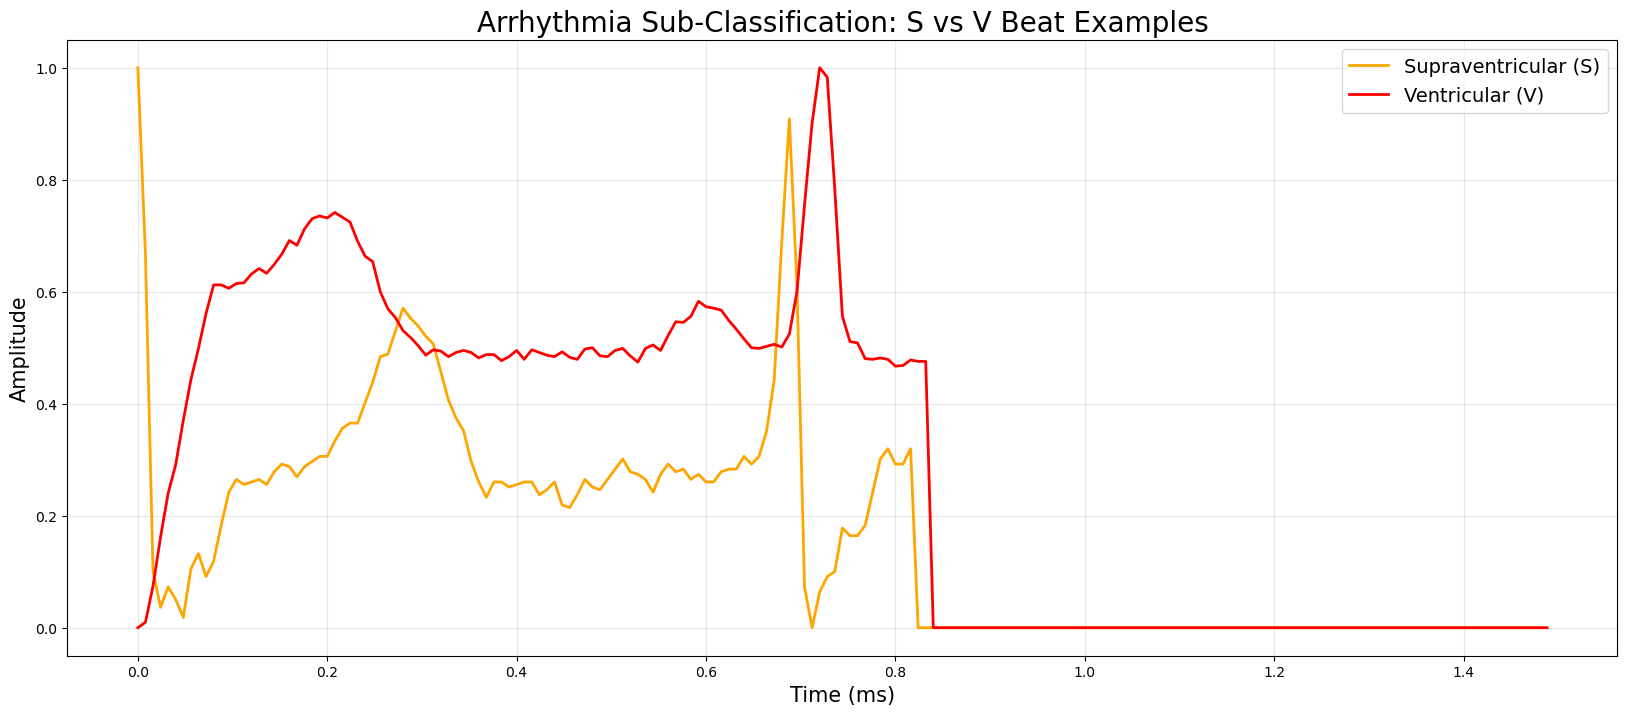

In [10]:
x = np.arange(0, 187)*8/1000

plt.figure(figsize=(20,8))
plt.plot(x, X[C0, :][0], label="Supraventricular (S)", linewidth=2, color='orange')
plt.plot(x, X[C1, :][0], label="Ventricular (V)", linewidth=2, color='red')
plt.legend(fontsize=14)
plt.title("Arrhythmia Sub-Classification: S vs V Beat Examples", fontsize=20)
plt.ylabel("Amplitude", fontsize=15)
plt.xlabel("Time (ms)", fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()

# Data Augmentation for Minority Class (S)
# S is the minority class (~28%), so we'll augment it to balance with V

In [11]:
def stretch(x):
    l = int(187 * (1 + (random.random()-0.5)/3))
    y = resample(x, l)
    if l < 187:
        y_ = np.zeros(shape=(187, ))
        y_[:l] = y
    else:
        y_ = y[:187]
    return y_

def amplify(x):
    alpha = (random.random()-0.5)
    factor = -alpha*x + (1+alpha)
    return x*factor

def augment(x):
    result = np.zeros(shape= (4, 187))
    for i in range(3):
        if random.random() < 0.33:
            new_y = stretch(x)
        elif random.random() < 0.66:
            new_y = amplify(x)
        else:
            new_y = stretch(x)
            new_y = amplify(new_y)
        result[i, :] = new_y
    return result

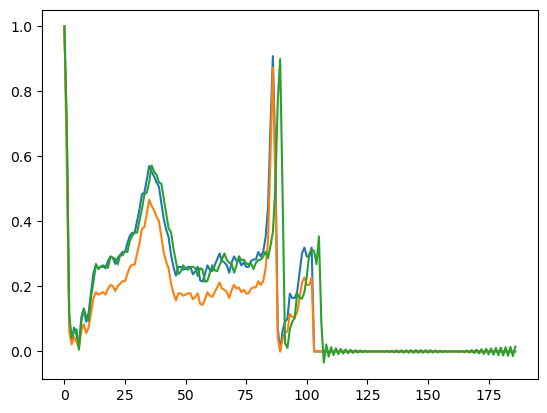

In [12]:
plt.plot(X[0, :])
plt.plot(amplify(X[0, :]))
plt.plot(stretch(X[0, :]))
plt.show()

In [13]:
# Augment S class (minority) to improve balance
# S is minority (~2779 samples) vs V (~7236 samples)
result = np.apply_along_axis(augment, axis=1, arr=X[C0]).reshape(-1, 187)
classe = np.zeros(shape=(result.shape[0],), dtype=int)  # All S (0)
X = np.vstack([X, result])
y = np.hstack([y, classe])

print(f"After augmentation:")
print(f"  Total samples: {len(y)}")
print(f"  Supraventricular (0): {np.sum(y == 0)} samples ({100*np.mean(y==0):.1f}%)")
print(f"  Ventricular (1): {np.sum(y == 1)} samples ({100*np.mean(y==1):.1f}%)")
print(f"\nBalance improved from ~28% S to {100*np.mean(y==0):.1f}% S")

After augmentation:
  Total samples: 21131
  Supraventricular (0): 13895 samples (65.8%)
  Ventricular (1): 7236 samples (34.2%)

Balance improved from ~28% S to 65.8% S


# Train/Test Split for S vs V Classification

In [14]:
# Recalculate indices after augmentation
C0 = np.argwhere(y == 0).flatten()
C1 = np.argwhere(y == 1).flatten()

# Balanced test set: equal samples per class
# Use smaller test set since we have fewer samples overall
n_test_per_class = 800
subC0 = np.random.choice(C0, n_test_per_class)
subC1 = np.random.choice(C1, n_test_per_class)

In [15]:
X_test = np.vstack([X[subC0], X[subC1]])
y_test = np.hstack([y[subC0], y[subC1]])

X_train = np.delete(X, [subC0, subC1], axis=0)
y_train = np.delete(y, [subC0, subC1], axis=0)

X_train, y_train = shuffle(X_train, y_train, random_state=0)
X_test, y_test = shuffle(X_test, y_test, random_state=0)

print(f"Training set:")
print(f"  Total: {len(y_train)} samples")
print(f"  Supraventricular (0): {np.sum(y_train == 0)} ({100*np.mean(y_train==0):.1f}%)")
print(f"  Ventricular (1): {np.sum(y_train == 1)} ({100*np.mean(y_train==1):.1f}%)")

print(f"\nTest set:")
print(f"  Total: {len(y_test)} samples")
print(f"  Supraventricular (0): {np.sum(y_test == 0)} ({100*np.mean(y_test==0):.1f}%)")
print(f"  Ventricular (1): {np.sum(y_test == 1)} ({100*np.mean(y_test==1):.1f}%)")

del X
del y

Training set:
  Total: 19605 samples
  Supraventricular (0): 13122 (66.9%)
  Ventricular (1): 6483 (33.1%)

Test set:
  Total: 1600 samples
  Supraventricular (0): 800 (50.0%)
  Ventricular (1): 800 (50.0%)


In [16]:
X_train = np.expand_dims(X_train, 2)
X_test = np.expand_dims(X_test, 2)

In [17]:
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (19605, 187, 1)
y_train (19605,)
X_test (1600, 187, 1)
y_test (1600,)


In [18]:
# For binary classification, keep as integer labels
# 0 = Supraventricular (S)
# 1 = Ventricular (V)

print("Using integer labels for S vs V classification")
print("y_train:", y_train.shape, y_train.dtype)
print("y_test:", y_test.shape, y_test.dtype)

Using integer labels for S vs V classification
y_train: (19605,) int64
y_test: (1600,) int64


In [19]:
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (19605, 187, 1)
y_train (19605,)
X_test (1600, 187, 1)
y_test (1600,)


# S vs V Classification Model
# Same architecture as Stage 1 for consistency

In [20]:
n_obs, feature, depth = X_train.shape
batch_size = 500

In [21]:
K.clear_session()

inp = Input(shape=(feature, depth))
C = Conv1D(filters=32, kernel_size=5, strides=1)(inp)

# Residual Block 1
C11 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
A11 = Activation("relu")(C11)
C12 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
S11 = Add()([C12, C])
A12 = Activation("relu")(S11)
M11 = MaxPooling1D(pool_size=5, strides=2)(A12)

# Residual Block 2
C21 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
A21 = Activation("relu")(C21)
C22 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
S21 = Add()([C22, M11])
A22 = Activation("relu")(S21)
M21 = MaxPooling1D(pool_size=5, strides=2)(A22)

# Residual Block 3
C31 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
A31 = Activation("relu")(C31)
C32 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
S31 = Add()([C32, M21])
A32 = Activation("relu")(S31)
M31 = MaxPooling1D(pool_size=5, strides=2)(A32)

# Residual Block 4
C41 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
A41 = Activation("relu")(C41)
C42 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
S41 = Add()([C42, M31])
A42 = Activation("relu")(S41)
M41 = MaxPooling1D(pool_size=5, strides=2)(A42)

# Residual Block 5
C51 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
A51 = Activation("relu")(C51)
C52 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
S51 = Add()([C52, M41])
A52 = Activation("relu")(S51)
M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

# Flatten and Dense layers
F1 = Flatten()(M51)
D1 = Dense(32)(F1)
A6 = Activation("relu")(D1)
D2 = Dense(32)(A6)

# Binary output: Single neuron with sigmoid activation
D3 = Dense(1)(D2)  # Changed from Dense(5) to Dense(1)
A7 = Activation("sigmoid")(D3)  # Changed from Softmax to sigmoid

model = Model(inputs=inp, outputs=A7)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 183, 32)   │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 183, 32)   │      5,152 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 183, 32)   │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 183, 32)   │      5,152 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 183, 32)   │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 183, 32)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 90, 32)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 90, 32)    │      5,152 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 90, 32)    │          0 │ conv1d_3[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 90, 32)    │      5,152 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 90, 32)    │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 90, 32)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 43, 32)    │          0 │ activation_3[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 43, 32)    │      5,152 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 43, 32)    │          0 │ conv1d_5[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 43, 32)    │      5,152 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 43, 32)    │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 43, 32)    │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                 

 Total params: 54,881 (214.38 KB)

 Trainable params: 54,881 (214.38 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
def exp_decay(epoch):
    initial_lrate = 0.001
    k = 0.75
    t = n_obs//(10000 * batch_size)  # every epoch we do n_obs/batch_size iteration
    lrate = initial_lrate * math.exp(-k*t)
    return lrate

lrate = LearningRateScheduler(exp_decay)

In [23]:
adam = Adam(learning_rate = 0.001, beta_1 = 0.9, beta_2 = 0.999)

In [24]:
# Remove the complex data processing - we already have the correct format
# X_train and X_test are already (N, 187, 1) shape
# y_train and y_test are already binary integers (0 or 1)

print("X_train:", X_train.shape, X_train.dtype)
print("X_test :", X_test.shape, X_test.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("y_test :", y_test.shape, y_test.dtype)

X_train: (19605, 187, 1) float64
X_test : (1600, 187, 1) float64
y_train: (19605,) int64
y_test : (1600,) int64


In [25]:
# Compile with binary crossentropy and metrics suitable for binary classification
from tensorflow.keras.metrics import AUC, Precision, Recall

model.compile(
    loss='binary_crossentropy',
    optimizer=adam,
    metrics=[
        'accuracy',
        AUC(name='auc'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

print("Model compiled for binary classification with binary_crossentropy loss")

Model compiled for binary classification with binary_crossentropy loss


In [26]:
# Train the S vs V sub-classifier
# Save best model checkpoint
checkpoint = ModelCheckpoint(
    r"best_model_subclass_s_v.h5",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

print("Training S vs V Sub-Classifier...")
print("This model will be used as Stage 2 in hierarchical classification")

history = model.fit(
    X_train, y_train, 
    epochs=75, 
    batch_size=batch_size, 
    verbose=2, 
    validation_data=(X_test, y_test), 
    callbacks=[lrate, checkpoint]
)

print("\nTraining completed!")
print(f"Best model saved to: best_model_subclass_s_v.h5")

Training S vs V Sub-Classifier...
This model will be used as Stage 2 in hierarchical classification
Epoch 1/75

Epoch 1: val_loss improved from None to 0.18954, saving model to best_model_subclass_s_v.h5


40/40 - 2s - 62ms/step - accuracy: 0.8530 - auc: 0.9211 - loss: 0.3377 - precision: 0.8124 - recall: 0.7222 - val_accuracy: 0.9206 - val_auc: 0.9860 - val_loss: 0.1895 - val_precision: 0.9746 - val_recall: 0.8637 - learning_rate: 1.0000e-03
Epoch 2/75

Epoch 2: val_loss improved from 0.18954 to 0.08216, saving model to best_model_subclass_s_v.h5


40/40 - 1s - 19ms/step - accuracy: 0.9585 - auc: 0.9918 - loss: 0.1096 - precision: 0.9387 - recall: 0.9355 - val_accuracy: 0.9663 - val_auc: 0.9959 - val_loss: 0.0822 - val_precision: 0.9674 - val_recall: 0.9650 - learning_rate: 1.0000e-03
Epoch 3/75

Epoch 3: val_loss did not improve from 0.08216
40/40 - 1s - 18ms/step - accuracy: 0.9737 - auc: 0.9962 - loss: 0.0716 - precision: 0.9594 - recall: 0.9611 - val_accuracy: 0.9513 - val_auc: 0.9965 - val_loss: 0.1319 - val_precision: 0.9130 - val_recall: 0.9975 - learning_rate: 1.0000e-03
Epoch 4/75

Epoch 4: val_loss improved from 0.08216 to 0.05837, saving model to best_model_subclass_s_v.h5


40/40 - 1s - 18ms/step - accuracy: 0.9754 - auc: 0.9970 - loss: 0.0645 - precision: 0.9582 - recall: 0.9679 - val_accuracy: 0.9787 - val_auc: 0.9978 - val_loss: 0.0584 - val_precision: 0.9764 - val_recall: 0.9812 - learning_rate: 1.0000e-03
Epoch 5/75

Epoch 5: val_loss improved from 0.05837 to 0.05781, saving model to best_model_subclass_s_v.h5


40/40 - 1s - 19ms/step - accuracy: 0.9821 - auc: 0.9979 - loss: 0.0492 - precision: 0.9733 - recall: 0.9727 - val_accuracy: 0.9775 - val_auc: 0.9978 - val_loss: 0.0578 - val_precision: 0.9763 - val_recall: 0.9787 - learning_rate: 1.0000e-03
Epoch 6/75

Epoch 6: val_loss improved from 0.05781 to 0.04775, saving model to best_model_subclass_s_v.h5


...

40/40 - 1s - 19ms/step - accuracy: 0.9948 - auc: 0.9997 - loss: 0.0161 - precision: 0.9930 - recall: 0.9912 - val_accuracy: 0.9900 - val_auc: 0.9998 - val_loss: 0.0250 - val_precision: 0.9962 - val_recall: 0.9837 - learning_rate: 1.0000e-03
Epoch 18/75

Epoch 18: val_loss did not improve from 0.02497
40/40 - 1s - 18ms/step - accuracy: 0.9957 - auc: 0.9998 - loss: 0.0127 - precision: 0.9940 - recall: 0.9931 - val_accuracy: 0.9906 - val_auc: 0.9996 - val_loss: 0.0256 - val_precision: 0.9925 - val_recall: 0.9887 - learning_rate: 1.0000e-03
Epoch 19/75

Epoch 19: val_loss improved from 0.02497 to 0.02367, saving model to best_model_subclass_s_v.h5


40/40 - 1s - 19ms/step - accuracy: 0.9947 - auc: 0.9996 - loss: 0.0162 - precision: 0.9923 - recall: 0.9917 - val_accuracy: 0.9900 - val_auc: 0.9996 - val_loss: 0.0237 - val_precision: 0.9912 - val_recall: 0.9887 - learning_rate: 1.0000e-03
Epoch 20/75

Epoch 20: val_loss did not improve from 0.02367
40/40 - 1s - 19ms/step - accuracy: 0.9957 - auc: 0.9999 - loss: 0.0118 - precision: 0.9935 - recall: 0.9935 - val_accuracy: 0.9894 - val_auc: 0.9996 - val_loss: 0.0266 - val_precision: 0.9863 - val_recall: 0.9925 - learning_rate: 1.0000e-03
Epoch 21/75

Epoch 21: val_loss did not improve from 0.02367
40/40 - 1s - 19ms/step - accuracy: 0.9953 - auc: 0.9997 - loss: 0.0138 - precision: 0.9929 - recall: 0.9929 - val_accuracy: 0.9919 - val_auc: 0.9985 - val_loss: 0.0257 - val_precision: 0.9950 - val_recall: 0.9887 - learning_rate: 1.0000e-03
Epoch 22/75

Epoch 22: val_loss did not improve from 0.02367
40/40 - 1s - 18ms/step - accuracy: 0.9958 - auc: 0.9997 - loss: 0.0118 - precision: 0.9949 - r

40/40 - 1s - 19ms/step - accuracy: 0.9980 - auc: 1.0000 - loss: 0.0063 - precision: 0.9974 - recall: 0.9965 - val_accuracy: 0.9925 - val_auc: 0.9998 - val_loss: 0.0224 - val_precision: 0.9975 - val_recall: 0.9875 - learning_rate: 1.0000e-03
Epoch 28/75

Epoch 28: val_loss improved from 0.02239 to 0.01419, saving model to best_model_subclass_s_v.h5


40/40 - 1s - 19ms/step - accuracy: 0.9983 - auc: 0.9999 - loss: 0.0054 - precision: 0.9980 - recall: 0.9969 - val_accuracy: 0.9956 - val_auc: 0.9999 - val_loss: 0.0142 - val_precision: 0.9975 - val_recall: 0.9937 - learning_rate: 1.0000e-03
Epoch 29/75

Epoch 29: val_loss did not improve from 0.01419
40/40 - 1s - 18ms/step - accuracy: 0.9987 - auc: 1.0000 - loss: 0.0043 - precision: 0.9977 - recall: 0.9983 - val_accuracy: 0.9950 - val_auc: 0.9993 - val_loss: 0.0178 - val_precision: 0.9975 - val_recall: 0.9925 - learning_rate: 1.0000e-03
Epoch 30/75

Epoch 30: val_loss did not improve from 0.01419
40/40 - 1s - 17ms/step - accuracy: 0.9989 - auc: 1.0000 - loss: 0.0033 - precision: 0.9986 - recall: 0.9981 - val_accuracy: 0.9937 - val_auc: 0.9993 - val_loss: 0.0153 - val_precision: 0.9937 - val_recall: 0.9937 - learning_rate: 1.0000e-03
Epoch 31/75

Epoch 31: val_loss did not improve from 0.01419
40/40 - 1s - 18ms/step - accuracy: 0.9993 - auc: 1.0000 - loss: 0.0028 - precision: 0.9992 - r

40/40 - 1s - 19ms/step - accuracy: 0.9991 - auc: 1.0000 - loss: 0.0024 - precision: 0.9989 - recall: 0.9985 - val_accuracy: 0.9956 - val_auc: 0.9993 - val_loss: 0.0118 - val_precision: 0.9950 - val_recall: 0.9962 - learning_rate: 1.0000e-03
Epoch 33/75

Epoch 33: val_loss did not improve from 0.01180
40/40 - 1s - 18ms/step - accuracy: 0.9987 - auc: 1.0000 - loss: 0.0035 - precision: 0.9986 - recall: 0.9974 - val_accuracy: 0.9950 - val_auc: 0.9999 - val_loss: 0.0126 - val_precision: 0.9962 - val_recall: 0.9937 - learning_rate: 1.0000e-03
Epoch 34/75

Epoch 34: val_loss did not improve from 0.01180
40/40 - 1s - 18ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 0.0013 - precision: 0.9995 - recall: 0.9995 - val_accuracy: 0.9969 - val_auc: 0.9993 - val_loss: 0.0141 - val_precision: 0.9963 - val_recall: 0.9975 - learning_rate: 1.0000e-03
Epoch 35/75

Epoch 35: val_loss did not improve from 0.01180
40/40 - 1s - 18ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 0.0013 - precision: 0.9997 - r

In [27]:
# Get predictions (probabilities)
y_pred_prob = model.predict(X_test, batch_size=1000).reshape(-1)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(f"Prediction probabilities shape: {y_pred_prob.shape}")
print(f"Binary predictions shape: {y_pred.shape}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Prediction probabilities shape: (1600,)
Binary predictions shape: (1600,)


In [28]:
# S vs V Classification Results
print("="*60)
print("S vs V SUB-CLASSIFIER RESULTS")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Supraventricular (S)", "Ventricular (V)"], digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("              Predicted")
print("                S       V")
print(f"Actual S     {cm[0,0]:>6}  {cm[0,1]:>6}")
print(f"       V     {cm[1,0]:>6}  {cm[1,1]:>6}")

# Additional metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.3f}")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

# PR curve metrics
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"PR-AUC: {pr_auc:.3f}")

# Best F1 threshold
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
best_idx = np.nanargmax(f1_scores)
best_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5
print(f"\nBest F1 Score: {f1_scores[best_idx]:.3f}")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"At best threshold - Precision: {precision[best_idx]:.3f}, Recall: {recall[best_idx]:.3f}")

print("\n" + "="*60)
print("STAGE 2 MODEL READY FOR HIERARCHICAL CLASSIFICATION")
print("="*60)

S vs V SUB-CLASSIFIER RESULTS

Classification Report:
                      precision    recall  f1-score   support

Supraventricular (S)      0.993     0.996     0.994       800
     Ventricular (V)      0.996     0.993     0.994       800

            accuracy                          0.994      1600
           macro avg      0.994     0.994     0.994      1600
        weighted avg      0.994     0.994     0.994      1600


Confusion Matrix:
              Predicted
                S       V
Actual S        797       3
       V          6     794

Accuracy: 0.994
ROC-AUC: 1.000
PR-AUC: 1.000

Best F1 Score: 0.997
Best Threshold: 0.040
At best threshold - Precision: 0.994, Recall: 1.000

STAGE 2 MODEL READY FOR HIERARCHICAL CLASSIFICATION


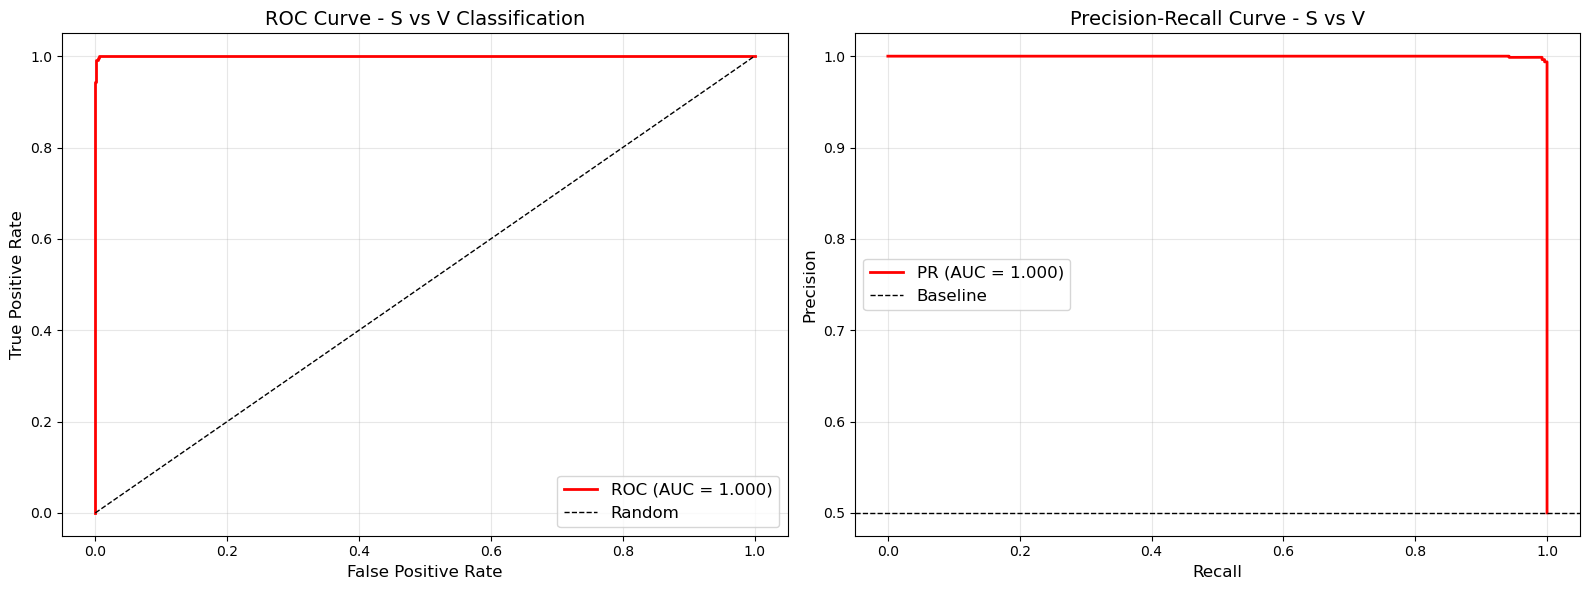

In [29]:
# Plot ROC and PR curves for S vs V classification
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax1.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})', color='red')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve - S vs V Classification', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve
ax2.plot(recall, precision, linewidth=2, label=f'PR (AUC = {pr_auc:.3f})', color='red')
ax2.axhline(y=np.mean(y_test), color='k', linestyle='--', linewidth=1, label='Baseline')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve - S vs V', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Confusion matrix, without normalization


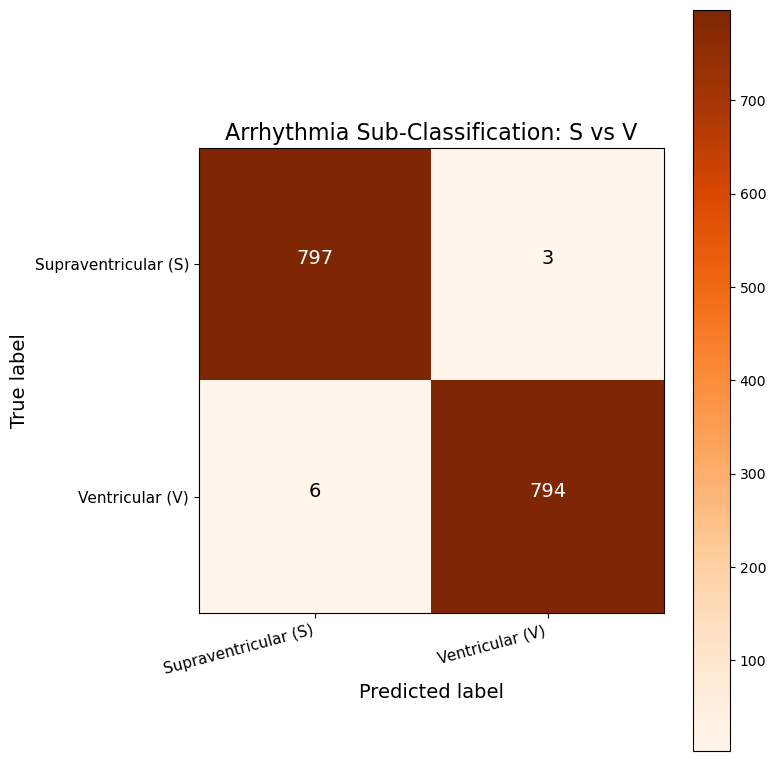


Sub-classifier ready for Stage 2 deployment!
Use this model AFTER Stage 1 detects arrhythmia


In [30]:
# S vs V confusion matrix visualization
def plot_sv_confusion_matrix(cm, normalize=False, title='S vs V Confusion Matrix'):
    """
    Plot confusion matrix for S vs V classification.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
    plt.title(title, fontsize=16)
    plt.colorbar()
    
    classes = ['Supraventricular (S)', 'Ventricular (V)']
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=11, rotation=15, ha='right')
    plt.yticks(tick_marks, classes, fontsize=11)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 fontsize=14,
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label', fontsize=14)
    plt.xlabel('Predicted label', fontsize=14)
    plt.tight_layout()
    plt.show()

# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot confusion matrix
plot_sv_confusion_matrix(cnf_matrix, 
                         title='Arrhythmia Sub-Classification: S vs V')

print("\n" + "="*60)
print("Sub-classifier ready for Stage 2 deployment!")
print("Use this model AFTER Stage 1 detects arrhythmia")
print("="*60)